Expects .asc files.

In [3]:
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm, CenteredNorm
from matplotlib.patches import Circle

import numpy as np
import os

import dLux.utils as dlu

data_dir = os.getcwd() + "/data/CL_Jan2026/"

Reading in phase data only.

In [104]:
fname = data_dir + "#3+4 gluing.asc"

if fname.endswith(".raw"):
    # intelliwave params from Alans sys (check corresponding .esg for more info)
    # 4-byte floating point format specified in waves
    # INVALID = 65535
    data = np.fromfile(fname, dtype=np.float32)
    shape = (512,512)
    WavelengthIn = 6.328e-07
    reshaped_phase_arr = np.reshape(data, shape)
    reshaped_phase_arr[reshaped_phase_arr > 65534] = np.nan
elif fname.endswith(".asc"):
    f = open(fname, "r")
    IntfScaleFactor, WavelengthIn, ObliquityFactor, R = None, None, None, None
    img_size_x, img_size_y = None, None
    hash_in, n_hashes = False, 0
    phase_img = []
    for i, line in enumerate(f):
        l = line.strip()
        l = l.split()

        if i == 3:
            img_size_x = int(l[2])
            img_size_y = int(l[3])
            print("Image size: ", img_size_x, "x", img_size_y)

        if i == 7:
            IntfScaleFactor = float(l[1])
            WavelengthIn = float(l[2])
            ObliquityFactor = float(l[4])
            print(
                "IntfScaleFactor: ",
                IntfScaleFactor,
                "WavelengthIn: ",
                WavelengthIn,
                "ObliquityFactor: ",
                ObliquityFactor,
            )

        elif i == 10:
            phaseres = float(l[0])
            if phaseres == 0.0:
                R = 4096
            elif phaseres == 1.0:
                R = 32768
            else:
                ValueError("Phase resolution not 0 or 1")
            print("Phase resolution: {}".format(R))

        if l[0] == "#" and hash_in:
            # 2nd hash signifies data end
            break

        if hash_in:
            data = np.asarray(l, dtype=np.float128)
            phase_img.append(data)

        if l[0] == "#" and not hash_in:
            n_hashes += 1

        if n_hashes == 2:
            hash_in = True

    phase_arr = np.concatenate(phase_img)
    reshaped_phase_arr = phase_arr.reshape(img_size_y, img_size_x)*(IntfScaleFactor*ObliquityFactor)/R #reshape and convert phase units to waves

    # filter for pseudo-NaNs 
    reshaped_phase_arr[reshaped_phase_arr == reshaped_phase_arr.max()] = np.nan

Image size:  1670 x 1700
IntfScaleFactor:  0.5 WavelengthIn:  6.328e-07 ObliquityFactor:  1.0
Phase resolution: 32768


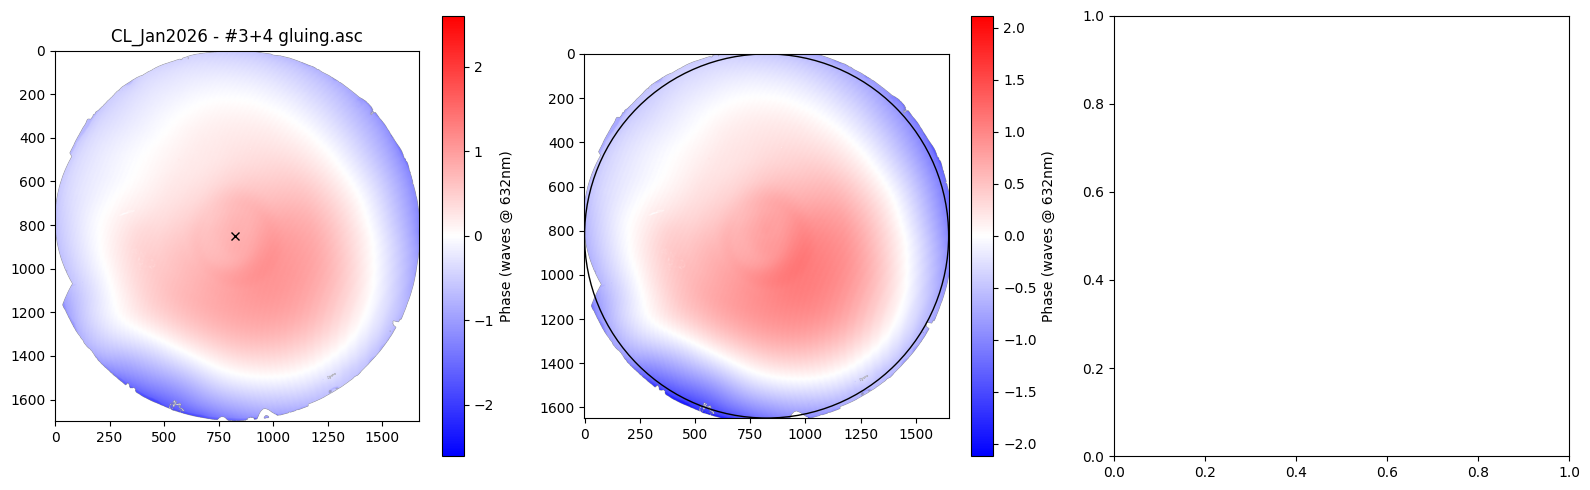

In [124]:
plt.figure(figsize=(16,5))
plt.subplot(1,3,1)  
cen = (int(reshaped_phase_arr.shape[0]//2*1), int(reshaped_phase_arr.shape[1]//2*1*0.99)) # row, col 
plt.imshow(reshaped_phase_arr, cmap='bwr', norm=CenteredNorm())
plt.colorbar(label='Phase (waves @ {:d}nm)'.format(int(WavelengthIn*1e9)))
plt.title("{} - {}".format(data_dir.split('/')[-2],fname.split("/")[-1]))
plt.plot(cen[1], cen[0], 'kx')
plt.subplot(1,3,2)  
radius = int(reshaped_phase_arr.shape[0]//2 * 0.97)
reshaped_phase_arr_cropped = reshaped_phase_arr[cen[0]-radius:cen[0]+radius, cen[1]-radius:cen[1]+radius]
plt.imshow(reshaped_phase_arr_cropped, cmap='bwr', norm=CenteredNorm())
new_cen = (reshaped_phase_arr_cropped.shape[0]//2, reshaped_phase_arr_cropped.shape[1]//2)
c = Circle(new_cen, radius=radius, edgecolor='k', facecolor='none')
ax = plt.gca()
ax.add_patch(c)
plt.colorbar(label='Phase (waves @ {:d}nm)'.format(int(WavelengthIn*1e9)))
plt.subplot(1,3,3)
# nan_mask = np.asarray(dlu.circle(coords=dlu.pixel_coords(npixels=radius*2, diameter=radius*2),radius=radius))
# nan_mask[nan_mask==0] = 0
# reshaped_phase_arr_cropped *= nan_mask
# plt.imshow(reshaped_phase_arr_cropped, cmap='bwr', norm=CenteredNorm())
# plt.colorbar(label='Phase (waves @ {:d}nm)'.format(int(WavelengthIn*1e9)))

plt.tight_layout()

In [125]:
np.save(fname[0:-4]+".npy", reshaped_phase_arr_cropped)

aside plotting

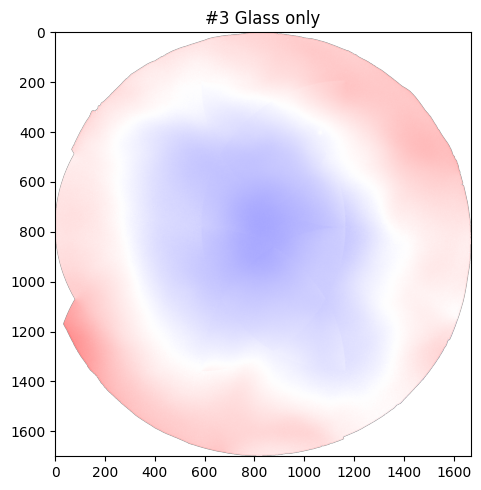

In [6]:
fnames = [
    "#3 Glass only.npy",
    # "#3 LCP Coating.npy",
    # "#4 Glass only.npy",
    # "#3+4 gluing.npy",
    # "TOLIMAN_USYDGlued_26022026_nomask.npy",
    # "TOLIMAN_CLGlued_26022026_nomask.npy",
    # "TOLIMAN_flight_26022026.npy",
]
plt.figure(figsize=(12,5))
for i, fname in enumerate(fnames):
    # if i == 0:
    #     phase_arr = np.load(os.getcwd() + "/data/CL_Jan2026/" + fname)
    # else: 
    phase_arr = np.load(data_dir + fname)
    # if i ==0:
    #     phase_arr[phase_arr > np.abs(np.nanmax(phase_arr))*0.35] = np.nan

    # crop to show central 125mm only 
    # circ_mask = dlu.circle(coords=dlu.pixel_coords(npixels=phase_arr.shape[0], diameter=phase_arr.shape[0]), radius=phase_arr.shape[0]//2*125/150)
    # circ_mask = circ_mask.at[circ_mask==0].set(np.nan)
    # phase_arr *= np.array(circ_mask)
    plt.subplot(1, len(fnames), i+1)
    plt.imshow(phase_arr, cmap='bwr', norm=CenteredNorm())
    # plt.colorbar(label='Phase (waves @ {:d}nm)'.format(int(WavelengthIn*1e9)))
    plt.title(fname[0:-4])
plt.tight_layout()

0 ----
[ 0.05320603 -0.01935637  0.00057913 -0.0032003  -0.00302318 -0.00086831
 -0.00180159 -0.01089432 -0.00217264  0.00279999  0.00018806 -0.00010876
 -0.00137885  0.00333303  0.00144022  0.00257553]


NameError: name 'WavelengthIn' is not defined

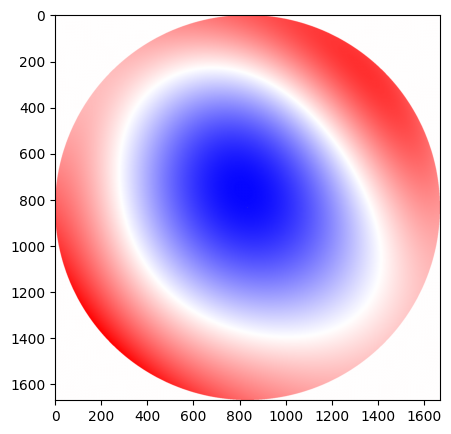

In [7]:
# fit with zernikes
import dLux.utils as dlu
aperture_diameter = 120e-3

plt.figure(figsize=(16,5))
for i, fname in enumerate(fnames):
    # if i == 0:
    #     phase_arr = np.load(os.getcwd() + "/data/CL_Jan2026/" + fname)
    # else: 
    phase_arr = np.load(data_dir + fname)
    CL_opd = np.array(phase_arr, dtype=np.float64)
    n_rows, n_cols = CL_opd.shape
    if n_cols != n_rows:
        cut_l = np.abs(n_rows - n_cols)
        is_odd = cut_l % 2
        if n_rows > n_cols:
            if is_odd:
                CL_opd = CL_opd[cut_l//2+1:-1-cut_l//2+1, :] 
            else:
                CL_opd = CL_opd[cut_l//2:-1-cut_l//2+1, :] 
        else:
            if is_odd:
                CL_opd = CL_opd[:, cut_l//2-2:-1-cut_l//2+1]
            else:
                CL_opd = CL_opd[:, cut_l//2:-1-cut_l//2+1]
    # if i ==0:
    #     CL_opd[CL_opd > np.abs(np.nanmax(CL_opd))*0.35] = np.nan
    # circ_mask = dlu.circle(coords=dlu.pixel_coords(npixels=phase_arr.shape[0], diameter=phase_arr.shape[0]), radius=phase_arr.shape[0]//2*125/150)
    # circ_mask = circ_mask.at[circ_mask==0].set(np.nan)
    # CL_opd *= np.array(circ_mask)

    CL_opd[~np.isfinite(CL_opd)] = 0 # Replace inf/nan with 0

    CL_coords = dlu.pixel_coords(npixels=CL_opd.shape[0], diameter=aperture_diameter)
    CL_zbasis = dlu.zernike_basis(js=np.arange(4,20), diameter=aperture_diameter, coordinates=CL_coords)
    CL_zbasis_rshp = np.vstack([basis.flatten() for basis in CL_zbasis]).T
    CL_zbasis_rshp[~np.isfinite(CL_zbasis_rshp)] = 0 # Replace inf/nan with 0
    pinv = np.linalg.pinv(CL_zbasis_rshp)

    est_coeffs = pinv@(CL_opd.flatten())
    print("{} ----".format(i))
    print(est_coeffs)
    retrieved = np.asarray([basis*est_coeffs[i] for i, basis in enumerate(CL_zbasis)]).sum(axis=0)
    plt.subplot(1, len(fnames), i+1)
    plt.imshow(retrieved, cmap='bwr', norm=CenteredNorm())
    plt.colorbar(label='Phase (waves @ {:d}nm)'.format(int(WavelengthIn*1e9)))
    plt.title(fname[0:-4])
plt.tight_layout()

In [ ]:
phase_arr = np.load(data_dir + "#3 LCP Coating.npy")
CL_opd = np.array(phase_arr, dtype=np.float64) 
n_rows, n_cols = CL_opd.shape
cut_l = np.abs(n_rows - n_cols)
is_odd = cut_l % 2
if n_rows > n_cols:
    if is_odd:
        CL_opd = CL_opd[cut_l//2+1:-1-cut_l//2+1, :] 
    else:
        CL_opd = CL_opd[cut_l//2:-1-cut_l//2+1, :] 
else:
    if is_odd:
        CL_opd = CL_opd[:, cut_l//2-2:-1-cut_l//2+1]
    else:
        CL_opd = CL_opd[:, cut_l//2:-1-cut_l//2+1]

CL_coords = dlu.pixel_coords(npixels=CL_opd.shape[0], diameter=aperture_diameter)
dlu_cover = dlu.circle(coords=CL_coords, radius=aperture_diameter/2.05)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(CL_opd*dlu_cover, cmap='bwr', norm=CenteredNorm())
plt.colorbar()

plt.subplot(1,2,2)
plt.imshow(dlu_cover, cmap='gray')
plt.colorbar()


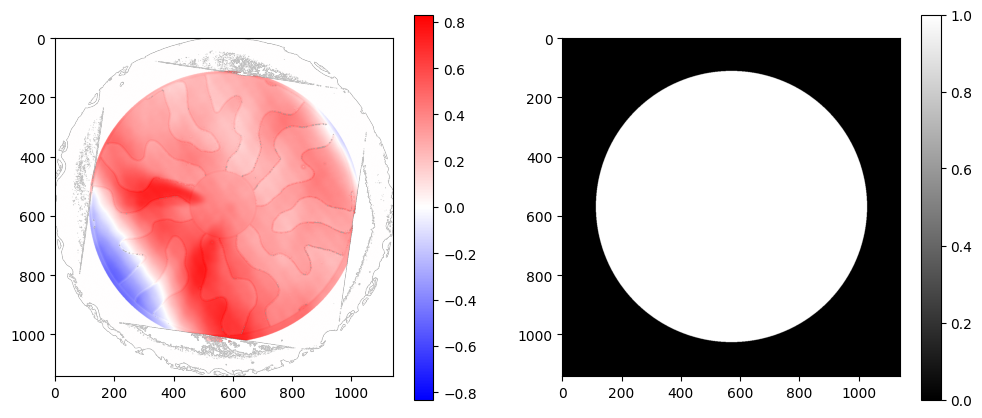

In [67]:
phase_arr = np.load(data_dir + "LCP Coating.npy")
CL_opd = np.array(phase_arr, dtype=np.float64) 
n_rows, n_cols = CL_opd.shape
cut_l = np.abs(n_rows - n_cols)
is_odd = cut_l % 2
if n_rows > n_cols:
    if is_odd:
        CL_opd = CL_opd[cut_l//2+1:-1-cut_l//2+1, :] 
    else:
        CL_opd = CL_opd[cut_l//2:-1-cut_l//2+1, :] 
else:
    if is_odd:
        CL_opd = CL_opd[:, cut_l//2-2:-1-cut_l//2+1]
    else:
        CL_opd = CL_opd[:, cut_l//2:-1-cut_l//2+1]

CL_coords = dlu.pixel_coords(npixels=CL_opd.shape[0], diameter=aperture_diameter)
dlu_cover = dlu.circle(coords=CL_coords, radius=aperture_diameter/2.5)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(CL_opd*dlu_cover, cmap='bwr', norm=CenteredNorm())
plt.colorbar()

plt.subplot(1,2,2)
plt.imshow(dlu_cover, cmap='gray')
plt.colorbar()
